# Implementação - CallMeMaybe
### Identificação de Operadores Ineficientes

A CallMeMaybe é uma empresa de telefonia virtual que oferece serviços de gestão de chamadas para organizações que lidam com grandes volumes de atendimento.

O objetivo deste notebook é analisar os dados de chamadas para identificar operadores ineficientes com base em três critérios:

- **Taxa de chamadas recebidas perdidas:** operadores que deixam muitas chamadas sem atendimento
- **Tempo de espera nas chamadas recebidas:** operadores que fazem os clientes esperarem muito
- **Volume de chamadas ativas realizadas:** operadores de saída que realizam poucas chamadas

Os resultados permitirão que supervisores tomem decisões baseadas em dados (realocando, treinando ou substituindo operadores de forma objetiva).

---

### Relatório Final: Formato CAR

**Challenge: o Problema:** Supervisores não tinham critério objetivo para identificar operadores ineficientes, sem esse critério, chamadas eram perdidas, clientes esperavam mais do que o aceitável e operadores de baixa produtividade passavam despercebidos.

**Actions: o que foi feito:**

1. Limpeza dos dados: remoção de 8.232 registros sem operador e 4.179 duplicatas. Dataset final: 41.491 registros.
2. Análise Exploratória: identificação de assimetria nos dados confirmada pelo teste de Shapiro-Wilk (p=0.0000).
3. Cálculo de 3 KPIs por operador usando função automatizada: taxa de perdas, tempo de espera e volume ativo.
4. Score de Ineficiência combinando os 3 KPIs com limites nos percentis 75 e 25.
5. Testes estatísticos: Spearman e Mann-Whitney com cálculo do tamanho do efeito (rank-biserial).

**Results:o que foi descoberto:** 104 operadores (9.5%) precisam de atenção imediata:
- 3 operadores Críticos: violam os 3 critérios simultaneamente
- 101 operadores Ineficientes: violam 2 critérios

Principais achados:
- **H1:** tempo de espera e chamadas perdidas têm associação significativa (Spearman=0.31, p<0.05)
- **H2:** chamadas internas e externas têm taxa de perdas igual (p=0.97) — efeito negligenciável (r=-0.0005)
- **H3:** diferença de produtividade entre grupos é real e expressiva (p<0.05, rank-biserial=1.0)

**Recomendação:** avaliar os 3 operadores críticos e iniciar programa de treinamento para os 101 ineficientes.

**Dashboard no Tableau:**
https://public.tableau.com/app/profile/steffany.cardoso/viz/CallMeMaybe-OperadoresInefiente/DashboardCallMeMaybe

**Relatório completo em PDF:** disponível no arquivo ZIP de entrega: https://drive.google.com/file/d/1QhYTlpztOyrokVL0BWaMB94ahhhPrQdh/view?usp=drive_link

### 2. Bibliotecas e Carregamento dos Dados:

In [ ]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro

# Carregando datasets
df = pd.read_csv('/datasets/telecom_dataset_us.csv')
clients = pd.read_csv('/datasets/telecom_clients_us.csv')

### 3. Visualização Inicial dos Dados:

In [1]:
# Visualizando datasets
print("DATASET PRINCIPAL")
print(f"Tamanho: {df.shape}")
print(df.head())
print(df.info())

print("\n")

print("DATASET DE CLIENTES")
print(f"Tamanho: {clients.shape}")
print(clients.head())
print(clients.info())

DATASET PRINCIPAL
Tamanho: (53902, 9)
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
3   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
4   166377  2019-08-05 00:00:00+03:00       out    False     880022.0   

   is_missed_call  calls_count  call_duration  total_call_duration  
0            True            2              0                    4  
1            True            3              0                    5  
2            True            1              0                    1  
3           False            1             10                   18  
4            True            3              0                   25  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 

**Dataset principal com 53.902 linhas e 9 colunas:**
- A coluna `date` está como texto e precisa de conversão para datetime.
- A coluna `internal` está como texto e precisa de conversão para booleano.
- A coluna `operator_id` está como float com 8.172 valores ausentes
(53.902 - 45.730 = 8.172 linhas sem operador atribuído).
- A coluna `internal` tem 117 valores ausentes.

**Dataset de clientes com 732 linhas e 3 colunas:**
- A coluna `date_start` está como texto e precisa de conversão para datetime.
- Sem valores ausentes.
- Todos os problemas identificados serão tratados na próxima etapa.

### 4. Limpeza e Preparação dos Dados:

- A coluna `date` estava como texto e foi convertida para datetime.
- A coluna `date_start` do dataset de clientes também estava como texto 
e foi convertida para datetime.
- A coluna `operator_id` estava como float porque o pandas converte 
automaticamente colunas inteiras que contêm valores ausentes para float,
já que o tipo int puro não aceita NaN. Foi convertida para Int64 
(com I maiúsculo), que é o tipo inteiro do pandas que aceita valores ausentes.
- A coluna `internal` já era booleana no arquivo original. 
O pandas a leu como object porque havia valores ausentes junto 
com os valores booleanos, o tipo bool puro não aceita NaN. 
Não foi necessária nenhuma conversão.

In [2]:
# Convertendo date para datetime
df['date'] = pd.to_datetime(df['date'], utc=True)

# Convertendo date_start do dataset de clientes para datetime
clients['date_start'] = pd.to_datetime(clients['date_start'])

# Verificando as conversões
print("Tipos de dados após conversão:")
print(df.dtypes)

Tipos de dados após conversão:
user_id                              int64
date                   datetime64[ns, UTC]
direction                           object
internal                            object
operator_id                        float64
is_missed_call                        bool
calls_count                          int64
call_duration                        int64
total_call_duration                  int64
dtype: object


**Conversão de Tipos de Dados:**
- A coluna `date` estava como texto e foi convertida para datetime.
- A coluna `date_start` do dataset de clientes também estava como 
texto e foi convertida para datetime.
- A coluna `internal` já era booleana no arquivo original mas o pandas 
a leu como object porque havia valores ausentes junto com os valores 
booleanos. Não foi necessária nenhuma conversão.

In [3]:
# Valores ausentes
print("Valores ausentes antes da remoção:")
print(df.isnull().sum())

# Removendo linhas sem operator_id e sem internal
df = df.dropna(subset=['operator_id', 'internal'])

print(f"\nTamanho após remoção: {df.shape}")
print(f"Linhas removidas: {53902 - len(df)}")
print("\nValores ausentes após remoção:")
print(df.isnull().sum())

Valores ausentes antes da remoção:
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Tamanho após remoção: (45670, 9)
Linhas removidas: 8232

Valores ausentes após remoção:
user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
dtype: int64


**Tratamento de Valores Ausentes:**
- A coluna `operator_id` tem 8.172 valores ausentes representando 
chamadas que entraram no sistema sem operador. Como o 
objetivo é analisar desempenho por operador, essas linhas serão removidas.
- A coluna `internal` tem 117 valores ausentes. Como é uma proporção 
pequena (0.2% do total) e não é possível identificar se a chamada foi 
interna ou externa, essas linhas também serão removidas.

In [4]:
# Convertendo operator_id para Int64
df['operator_id'] = df['operator_id'].astype('Int64')

# Verificando duplicatas
duplicatas = df.duplicated().sum()
print(f"Linhas duplicadas: {duplicatas}")

# Verificando tipos após conversão
print("\nTipos de dados após conversão:")
print(df.dtypes)

Linhas duplicadas: 4179

Tipos de dados após conversão:
user_id                              int64
date                   datetime64[ns, UTC]
direction                           object
internal                            object
operator_id                          Int64
is_missed_call                        bool
calls_count                          int64
call_duration                        int64
total_call_duration                  int64
dtype: object


**Conversão de operator_id e Verificação de Duplicatas:**
- Após a remoção dos valores ausentes, convertemos `operator_id` 
para Int64.
- Em seguida verificamos se existem linhas duplicadas no dataset.

In [5]:
# Visualizando duplicatas
print("Exemplo de linhas duplicadas:")
print(df[df.duplicated(keep=False)].sort_values(
    ['operator_id', 'date', 'direction']
).head(10))

Exemplo de linhas duplicadas:
      user_id                      date direction internal  operator_id  \
1796   166406 2019-08-05 21:00:00+00:00       out    False       879896   
1798   166406 2019-08-05 21:00:00+00:00       out    False       879896   
1807   166406 2019-08-07 21:00:00+00:00        in    False       879896   
1814   166406 2019-08-07 21:00:00+00:00        in    False       879896   
1831   166406 2019-08-11 21:00:00+00:00       out    False       879896   
1834   166406 2019-08-11 21:00:00+00:00       out    False       879896   
1891   166406 2019-08-26 21:00:00+00:00        in    False       879896   
1892   166406 2019-08-26 21:00:00+00:00        in    False       879896   
1905   166406 2019-08-29 21:00:00+00:00       out    False       879896   
1912   166406 2019-08-29 21:00:00+00:00       out    False       879896   

      is_missed_call  calls_count  call_duration  total_call_duration  
1796           False           35           4119                 4489  


**Duplicatas:** As 4.179 linhas duplicadas são registros completamente idênticos em todas as colunas (mesmo operador, mesma data, mesma direção 
e mesmos valores de chamadas). Provavelmente são erros de registro no 
sistema e não de chamadas reais distintas. Serão removidas.

In [6]:
# Removendo duplicatas
df = df.drop_duplicates()

print(f"Tamanho após remoção de duplicatas: {df.shape}")
print(f"Linhas removidas: {45670 - len(df)}")

Tamanho após remoção de duplicatas: (41491, 9)
Linhas removidas: 4179


In [7]:
# Unindo os dois datasets
df = df.merge(clients, on='user_id', how='left')

print(f"Tamanho após união: {df.shape}")
print("\nPrimeiras linhas após união:")
print(df.head())

print("\nValores ausentes após união:")
print(df.isnull().sum())

Tamanho após união: (41491, 11)

Primeiras linhas após união:
   user_id                      date direction internal  operator_id  \
0   166377 2019-08-04 21:00:00+00:00       out     True       880022   
1   166377 2019-08-04 21:00:00+00:00       out     True       880020   
2   166377 2019-08-04 21:00:00+00:00       out     True       880020   
3   166377 2019-08-04 21:00:00+00:00       out    False       880022   
4   166377 2019-08-04 21:00:00+00:00       out    False       880020   

   is_missed_call  calls_count  call_duration  total_call_duration  \
0            True            3              0                    5   
1            True            1              0                    1   
2           False            1             10                   18   
3            True            3              0                   25   
4           False            2              3                   29   

  tariff_plan date_start  
0           B 2019-08-01  
1           B 2019-08-01  
2  

**Resumo da Limpeza e Preparação dos Dados:**

| Etapa | Linhas | Alteração |
|---|---|---|
| Dataset original | 53.902 | |
| Remoção de ausentes | 45.670 | -8.232 linhas |
| Remoção de duplicatas | 41.491 | -4.179 linhas |
| União com clientes | 41.491 | +2 colunas |

O dataset final tem 41.491 linhas e 11 colunas, sem valores 
ausentes e com todos os tipos de dados corretos.
Está pronto para a análise

### 5. Análise Exploratória dos Dados (EDA):

In [8]:
# Distribuição de chamadas de entrada e saída
print("Distribuição de chamadas de entrada e saída:")
print(df['direction'].value_counts())
print()
print("Proporção:")
print(df['direction'].value_counts(normalize=True).round(4) * 100)

Distribuição de chamadas de entrada e saída:
out    28813
in     12678
Name: direction, dtype: int64

Proporção:
out    69.44
in     30.56
Name: direction, dtype: float64


**Distribuição de chamadas de entrada e saída:** O dataset contém 28.813 chamadas de saída (69.44%) e 12.678 chamadas de entrada (30.56%).

A maioria das chamadas é de saída, mostrando que os operadores fazem mais ligações do que recebem. Por isso, é importante analisar chamadas de entrada e saída separadamente, já que cada tipo possui critérios diferentes para identificar ineficiência.

In [9]:
# Distribuião de chamas internas vs externas
print("Distribuição de chamadas internas vs externas:")
print(df['internal'].value_counts())
print()
print("Proporção:")
print(df['internal'].value_counts(normalize=True).round(4) * 100)

Distribuição de chamadas internas vs externas:
False    36161
True      5330
Name: internal, dtype: int64

Proporção:
False    87.15
True     12.85
Name: internal, dtype: float64


**Distribuição de Chamadas Internas vs Externas:** O dataset contém 36.161 chamadas externas (87.15%) e 5.330 chamadas internas (12.85%).

A maioria das chamadas acontece com clientes externos, enquanto apenas 12,85% são chamadas internas entre operadores. Essa diferença é importante para a Hipótese 2, que busca verificar se a quantidade de chamadas perdidas muda entre chamadas internas e externas.

In [10]:
# Total de chamadas perdidas
print("Total de chamadas perdidas:")
print(df['is_missed_call'].value_counts())
print()
print("Proporção geral:")
print(df['is_missed_call'].value_counts(normalize=True).round(4) * 100)

# Chamadas perdidas apenas nas chamadas de entrada
chamadas_entrada = df[df['direction'] == 'in']
print("\nChamadas perdidas apenas nas chamadas de entrada:")
print(chamadas_entrada['is_missed_call'].value_counts())
print()
print("Proporção nas chamadas de entrada:")
print(chamadas_entrada['is_missed_call'].value_counts(normalize=True).round(4) * 100)

Total de chamadas perdidas:
False    27382
True     14109
Name: is_missed_call, dtype: int64

Proporção geral:
False    66.0
True     34.0
Name: is_missed_call, dtype: float64

Chamadas perdidas apenas nas chamadas de entrada:
False    11994
True       684
Name: is_missed_call, dtype: int64

Proporção nas chamadas de entrada:
False    94.6
True      5.4
Name: is_missed_call, dtype: float64


**Análise de Chamadas Perdidas:** No total, 34% das chamadas são perdidas, mas esse valor também considera chamadas de saída que não foram atendidas. Para a análise, o mais importante é observar as chamadas de entrada, das quais apenas 5,4% não foram atendidas. Por isso, separar as chamadas por direção evita uma interpretação errada do desempenho dos operadores.

Estatísticas do tempo de espera nas chamadas de entrada:
count    12678.00
mean        97.20
std        185.59
min          0.00
25%         17.00
50%         38.00
75%         97.00
max       3998.00
Name: wait_time, dtype: float64


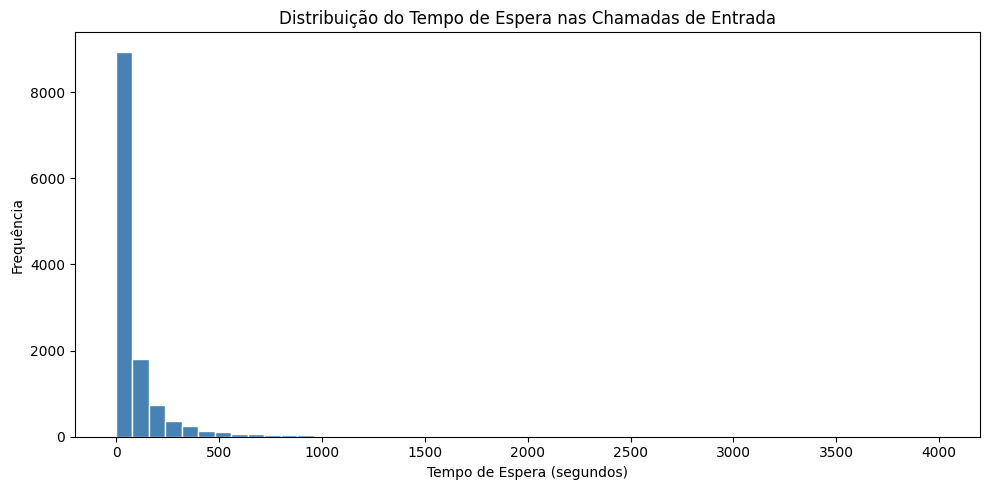

In [11]:
# Calculando o tempo de espera
df['wait_time'] = df['total_call_duration'] - df['call_duration']

# Analisando apenas chamadas de entrada
espera_entrada = df[df['direction'] == 'in']['wait_time']

print("Estatísticas do tempo de espera nas chamadas de entrada:")
print(espera_entrada.describe().round(2))

# Visualizando a distribuição
plt.figure(figsize=(10, 5))
plt.hist(espera_entrada, bins=50, color='steelblue', edgecolor='white')
plt.title('Distribuição do Tempo de Espera nas Chamadas de Entrada')
plt.xlabel('Tempo de Espera (segundos)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig('tempo_espera.png', bbox_inches='tight')
plt.show()

**Tempo de Espera:** O tempo de espera foi calculado como a diferença entre 
`total_call_duration` e `call_duration`.

Nas chamadas de entrada, a média de espera é de 97 segundos, enquanto a mediana é de 38 segundos. Essa diferença acontece devido à presença de valores muito altos, como o máximo de 3.998 segundos, cerca de 67 minutos. Por isso, a mediana representa melhor o tempo de espera típico. Além disso, para a Hipótese 1, o teste de Spearman é mais adequado do que o de Pearson, já que os dados apresentam uma distribuição assimétrica e valores extremos.

Estatísticas do volume de chamadas ativas por operador:
count      882.00
mean       689.73
std       3122.95
min          1.00
25%         11.00
50%         90.00
75%        597.25
max      58977.00
Name: calls_count, dtype: float64


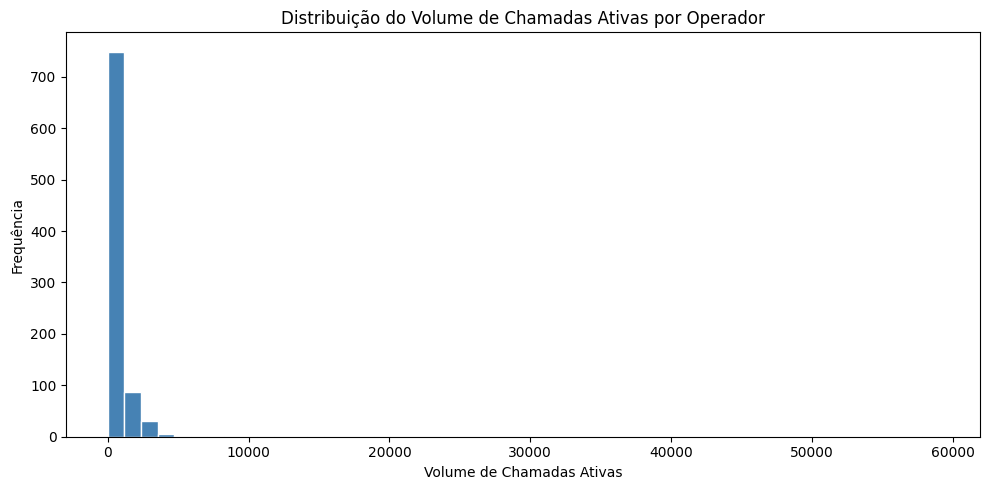

In [12]:
# Volume de chamadas ativas
# Filtrando apenas chamadas de saída
chamadas_saida = df[df['direction'] == 'out']

# Calculando o volume de chamadas ativas por operador
volume_ativo = chamadas_saida.groupby('operator_id')['calls_count'].sum()

print("Estatísticas do volume de chamadas ativas por operador:")
print(volume_ativo.describe().round(2))

# Visualizando a distribuição
plt.figure(figsize=(10, 5))
plt.hist(volume_ativo, bins=50, color='steelblue', edgecolor='white')
plt.title('Distribuição do Volume de Chamadas Ativas por Operador')
plt.xlabel('Volume de Chamadas Ativas')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig('volume_ativo.png', bbox_inches='tight')
plt.show()

**Análise do Volume de Chamadas Ativas:** O volume de chamadas ativas foi calculado somando `calls_count` por operador nas chamadas de saída.

São 882 operadores responsáveis pelas chamadas de saída. A média é de 690 chamadas por operador, enquanto a mediana é de apenas 90 chamadas. Essa grande diferença acontece porque alguns operadores possuem um número muito alto de chamadas, chegando ao máximo de 58.977. Esses valores extremos aumentam a média e tornam a distribuição assimétrica. Por isso, a mediana representa melhor o volume típico de chamadas realizadas pelos operadores.

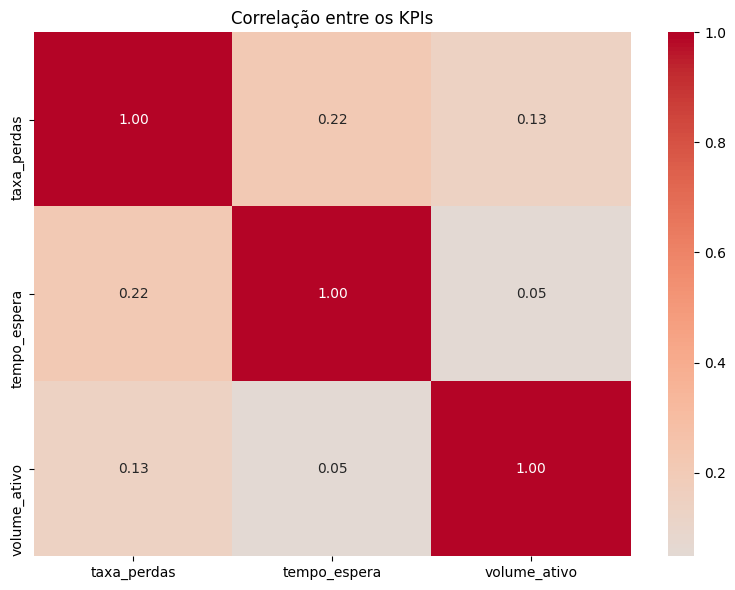

In [13]:
# Correlação com os KPIs
# Calculando as métricas por operador para a correlação
# Taxa de chamadas perdidas nas chamadas de entrada
taxa_perdas = df[df['direction'] == 'in'].groupby('operator_id').apply(
    lambda x: x['is_missed_call'].sum() / len(x)
).rename('taxa_perdas')

# Tempo médio de espera nas chamadas de entrada
tempo_espera = df[df['direction'] == 'in'].groupby(
    'operator_id')['wait_time'].median().rename('tempo_espera')

# Volume de chamadas ativas
volume_ativo = df[df['direction'] == 'out'].groupby(
    'operator_id')['calls_count'].sum().rename('volume_ativo')

# Unindo as métricas em um dataframe
kpis = pd.concat([taxa_perdas, tempo_espera, volume_ativo], axis=1)

# Calculando e visualizando a correlação
plt.figure(figsize=(8, 6))
sns.heatmap(
    kpis.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlação entre os KPIs')
plt.tight_layout()
plt.savefig('correlacao_kpis.png', bbox_inches='tight')
plt.show()

**Correlação entre KPIs:** A análise mostra que os três KPIs possuem baixa correlação entre si, indicando que avaliam diferentes aspectos do desempenho dos operadores.

A maior correlação é entre a taxa de chamadas perdidas e o tempo de espera (0,22). Apesar de fraca, ela indica que tempos de espera maiores podem estar relacionados a mais chamadas perdidas. Essa relação será analisada na Hipótese 1.

Já o volume de chamadas de saída apresenta correlação muito baixa com os outros KPIs (0,13 e 0,05).

Dessa forma, faz sentido combinar os três indicadores em um Score de Ineficiência, permitindo avaliar diferentes aspectos do desempenho dos operadores.

In [14]:
# Teste de normalidade: Shapiro-Wilk
variaveis = {
    'Taxa de Perdas': df[df['direction'] == 'in']['is_missed_call'].astype(float),
    'Tempo de Espera': df[df['direction'] == 'in']['wait_time'],
    'Volume Ativo': df[df['direction'] == 'out']['calls_count'].astype(float)
}

print("TESTE DE NORMALIDADE: SHAPIRO-WILK\n")

for nome, dados in variaveis.items():
    stat, p = shapiro(dados.sample(min(5000, len(dados)), random_state=42))
    normalidade = "Normal" if p > 0.05 else "Não normal"
    print(f"{nome}:")
    print(f"  Estatística: {stat:.4f}")
    print(f"  p-value: {p:.4f}")
    print(f"  Resultado: {normalidade}")
    print()

TESTE DE NORMALIDADE: SHAPIRO-WILK

Taxa de Perdas:
  Estatística: 0.2342
  p-value: 0.0000
  Resultado: Não normal

Tempo de Espera:
  Estatística: 0.4631
  p-value: 0.0000
  Resultado: Não normal

Volume Ativo:
  Estatística: 0.2446
  p-value: 0.0000
  Resultado: Não normal



**Teste de Normalidade: Shapiro-Wilk:** O teste de Shapiro-Wilk mostrou que nenhuma das três variáveis apresenta distribuição normal, com p-value = 0.0000 para todas. Esse resultado confirma a escolha de testes não paramétricos para as hipóteses:
- Hipótese 1: Correlação de Spearman
- Hipóteses 2 e 3: Teste de Mann-Whitney

O resultado também está de acordo com a análise exploratória dos dados, que mostrou distribuições assimétricas e presença de valores extremos.

### 6. Cálculo dos KPIs por Operador:

In [ ]:
# Função para calcular KPIs POR OPERADOR
def calcular_kpi(df, coluna, direcao, agregacao, nome_kpi):
    df_filtrado = df[df['direction'] == direcao]
    resultado = (
        df_filtrado
        .groupby('operator_id')[coluna]
        .agg(agregacao)
        .rename(nome_kpi)
        .reset_index()
    )
    return resultado

In [15]:
# KPI 1: Taxa de chamadas recebidas perdidas
taxa_perdas = calcular_kpi(df, 'is_missed_call', 'in', 'mean', 'taxa_perdas')
print("Taxa de chamadas perdidas por operador:")
print(taxa_perdas.describe().round(4))
print(f"Percentil 75: {taxa_perdas['taxa_perdas'].quantile(0.75):.4f}")

print()

# KPI 2: Tempo mediano de espera nas chamadas de entrada
tempo_espera = calcular_kpi(df, 'wait_time', 'in', 'median', 'tempo_espera')
print("Tempo mediano de espera por operador (segundos):")
print(tempo_espera.describe().round(2))
print(f"Percentil 75: {tempo_espera['tempo_espera'].quantile(0.75):.2f} segundos")

print()

# KPI 3: Volume total de chamadas ativas de saída
volume_ativo = calcular_kpi(df, 'calls_count', 'out', 'sum', 'volume_ativo')
print("Volume de chamadas ativas por operador:")
print(volume_ativo.describe().round(2))
print(f"Percentil 25: {volume_ativo['volume_ativo'].quantile(0.25):.2f} chamadas")

Taxa de chamadas perdidas por operador:
       operator_id  taxa_perdas
count     754.0000     754.0000
mean   923704.4005       0.0373
std     22646.7338       0.0847
min    879896.0000       0.0000
25%    905153.0000       0.0000
50%    924580.0000       0.0000
75%    940457.5000       0.0381
max    973286.0000       1.0000
Percentil 75: 0.0381

Tempo mediano de espera por operador (segundos):
       operator_id  tempo_espera
count       754.00        754.00
mean     923704.40         50.38
std       22646.73         90.89
min      879896.00          1.00
25%      905153.00         15.00
50%      924580.00         25.00
75%      940457.50         48.00
max      973286.00        953.00
Percentil 75: 48.00 segundos

Volume de chamadas ativas por operador:
       operator_id  volume_ativo
count       882.00        882.00
mean     925658.34        689.73
std       22862.56       3122.95
min      879896.00          1.00
25%      906394.50         11.00
50%      924959.00         90.00
75%

**Cálculo dos KPIs por Operador:** Os três KPIs foram calculados com a função calcular_kpi, que facilita o processo de filtrar as chamadas, agrupar os dados por operador e calcular cada indicador.
- **KPI 1: Taxa de Chamadas Recebidas Perdidas:** Dos 754 operadores que recebem chamadas, a maioria não possui chamadas perdidas, com mediana de 0%. O limite para sinalização é o percentil 75 de 3,81%.
- **KPI 2: Tempo Mediano de Espera:**
O tempo mediano de espera é de 25 segundos por operador. O limite para sinalização é o percentil 75 de 48 segundos. A mediana foi utilizada porque os dados são assimétricos, como confirmado pelo teste de Shapiro-Wilk.
- **KPI 3: Volume de Chamadas Ativas:**  São 882 operadores responsáveis pelas chamadas de saída, com uma mediana de 90 chamadas por operador. O limite para sinalização é o percentil 25 de 11 chamadas. Operadores abaixo desse valor são considerados com baixo volume de chamadas de saída.

In [16]:
# Taxa de chamadas recebidas perdidas
# Filtrando apenas chamadas de entrada
entrada = df[df['direction'] == 'in']

# Calculando a taxa de perdas por operador
taxa_perdas = entrada.groupby('operator_id').apply(
    lambda x: x['is_missed_call'].sum() / len(x)
).rename('taxa_perdas').reset_index()

print("Taxa de chamadas perdidas por operador:")
print(taxa_perdas.describe().round(4))
print()
print(f"Percentil 75: {taxa_perdas['taxa_perdas'].quantile(0.75):.4f}")

Taxa de chamadas perdidas por operador:
       operator_id  taxa_perdas
count     754.0000     754.0000
mean   923704.4005       0.0373
std     22646.7338       0.0847
min    879896.0000       0.0000
25%    905153.0000       0.0000
50%    924580.0000       0.0000
75%    940457.5000       0.0381
max    973286.0000       1.0000

Percentil 75: 0.0381


**Taxa de Chamadas Recebidas Perdidas:** Dos 754 operadores que recebem chamadas de entrada, a maioria não apresenta chamadas perdidas, resultando em uma mediana de 0%. O percentil 75 é de 3,81% e será usado como limite. Assim, operadores com uma taxa acima desse valor serão sinalizados com alta taxa de chamadas recebidas perdidas.

In [17]:
# Tempo médio de espera
# Calculando o tempo mediano de espera por operador
tempo_espera = entrada.groupby('operator_id')['wait_time'].median(
).rename('tempo_espera').reset_index()

print("Tempo mediano de espera por operador (segundos):")
print(tempo_espera.describe().round(2))
print()
print(f"Percentil 75: {tempo_espera['tempo_espera'].quantile(0.75):.2f} segundos")

Tempo mediano de espera por operador (segundos):
       operator_id  tempo_espera
count       754.00        754.00
mean     923704.40         50.38
std       22646.73         90.89
min      879896.00          1.00
25%      905153.00         15.00
50%      924580.00         25.00
75%      940457.50         48.00
max      973286.00        953.00

Percentil 75: 48.00 segundos


**Tempo Médio de Espera:** Como os dados são assimétricos, foi usada a mediana do tempo de espera por operador. A mediana geral é de 25 segundos, e o percentil 75 é de 48 segundos. Operadores acima desse limite serão considerados com espera prolongada. O maior valor encontrado foi de 953 segundos, cerca de 16 minutos, indicando casos de desempenho muito abaixo do esperado.

In [18]:
# Volume de chamadas ativas
# Filtrando apenas chamadas de saída
saida = df[df['direction'] == 'out']

# Calculando o volume de chamadas ativas por operador
volume_ativo = saida.groupby('operator_id')['calls_count'].sum(
).rename('volume_ativo').reset_index()

print("Volume de chamadas ativas por operador:")
print(volume_ativo.describe().round(2))
print()
print(f"Percentil 25: {volume_ativo['volume_ativo'].quantile(0.25):.2f} chamadas")

Volume de chamadas ativas por operador:
       operator_id  volume_ativo
count       882.00        882.00
mean     925658.34        689.73
std       22862.56       3122.95
min      879896.00          1.00
25%      906394.50         11.00
50%      924959.00         90.00
75%      943630.00        597.25
max      973120.00      58977.00

Percentil 25: 11.00 chamadas


**Volume de Chamadas Ativas:** São 882 operadores responsáveis pelas chamadas de saída, com uma mediana de 90 chamadas por operador. O percentil 25 é de 11 chamadas e será usado como limite. Operadores abaixo desse valor serão considerados com baixo volume de chamadas de saída. O máximo de 58.977 chamadas mostra a presença de valores extremos, por isso o percentil é uma referência mais adequada do que a média.

In [19]:
# Score de ineficiência
# Definindo os limites de cada KPI
limite_taxa_perdas = taxa_perdas['taxa_perdas'].quantile(0.75)
limite_tempo_espera = tempo_espera['tempo_espera'].quantile(0.75)
limite_volume_ativo = volume_ativo['volume_ativo'].quantile(0.25)

# Unindo os três KPIs em um único dataframe
kpis_operadores = taxa_perdas.merge(
    tempo_espera, on='operator_id', how='outer'
).merge(
    volume_ativo, on='operator_id', how='outer'
)

# Calculando o score de ineficiência
kpis_operadores['score'] = 0

# Critério 1: taxa de perdas acima do percentil 75
kpis_operadores['score'] += (
    kpis_operadores['taxa_perdas'] > limite_taxa_perdas
).astype(int)

# Critério 2: tempo de espera acima do percentil 75
kpis_operadores['score'] += (
    kpis_operadores['tempo_espera'] > limite_tempo_espera
).astype(int)

# Critério 3: volume ativo abaixo do percentil 25
kpis_operadores['score'] += (
    kpis_operadores['volume_ativo'] < limite_volume_ativo
).astype(int)

# Classificando os operadores
def classificar(score):
    if score == 0:
        return 'Eficiente'
    elif score == 1:
        return 'Atenção'
    elif score == 2:
        return 'Ineficiente'
    else:
        return 'Crítico'

kpis_operadores['classificacao'] = kpis_operadores['score'].apply(classificar)

# Visualizando a distribuição das classificações
print("Distribuição das classificações:")
print(kpis_operadores['classificacao'].value_counts())
print()
print(f"Total de operadores analisados: {len(kpis_operadores)}")

Distribuição das classificações:
Eficiente      611
Atenção        377
Ineficiente    101
Crítico          3
Name: classificacao, dtype: int64

Total de operadores analisados: 1092


**Score de Ineficiência:** O Score de Ineficiência combina os três KPIs em uma 
classificação única por operador. Cada critério violado 
soma 1 ponto ao score:
- Taxa de perdas acima do percentil 75 (3.81%) → +1 ponto
- Tempo de espera acima do percentil 75 (48 segundos) → +1 ponto
- Volume ativo abaixo do percentil 25 (11 chamadas) → +1 ponto

De 1.092 operadores analisados:
- 56% são Eficientes (score 0)
- 34% estão em Atenção (score 1)
- 9.2% são Ineficientes (score 2)
- 0.3% são Críticos (score 3)

**104 operadores (9.5% do total) precisam de atenção imediata
e serão detalhados na Etapa 8.**

### 7. Testes Estatísticos:

In [20]:
# HIPÓTESE 1: tempo de espera e chamadas perdidas
# Unindo taxa de perdas e tempo de espera por operador
h1_dados = taxa_perdas.merge(tempo_espera, on='operator_id')

# Removendo valores ausentes
h1_dados = h1_dados.dropna()

# Aplicando o teste de correlação de Spearman
correlacao, p_value = stats.spearmanr(
    h1_dados['taxa_perdas'],
    h1_dados['tempo_espera']
)

print("HIPÓTESE 1: Spearman")
print(f"Correlação de Spearman: {correlacao:.4f}")
print(f"p-value: {p_value:.4f}")
print()

if p_value < 0.05:
    print("Rejeitamos H0")
    print("Existe associação significativa entre tempo de espera e chamadas perdidas")
else:
    print("Não rejeitamos H0")
    print("Não existe associação significativa entre tempo de espera e chamadas perdidas")

HIPÓTESE 1: Spearman
Correlação de Spearman: 0.3145
p-value: 0.0000

Rejeitamos H0
Existe associação significativa entre tempo de espera e chamadas perdidas


**Hipótese 1: Relação entre Tempo de Espera e Chamadas Perdidas:** Teste utilizado: Correlação de Spearman, escolhida por ser adequada para dados assimétricos e relações não lineares.

Resultado:
- Correlação de Spearman = 0.31
- p-value = 0.0000
  
Rejeitamos H0. Existe associação estatisticamente significativa entre o tempo de espera e a taxa de chamadas recebidas perdidas.

A correlação positiva de 0.31 indica que operadores com maior tempo de espera tendem a ter mais chamadas perdidas. Embora a correlação seja fraca a moderada, o resultado é estatisticamente robusto e justifica combinar os dois indicadores no Score de Ineficiência.

In [21]:
# HIPÓTESE 2: chamadas internas vs externas
# Filtrando chamadas de entrada perdidas e não perdidas
# separando por tipo (interna vs externa)
internas = df[(df['direction'] == 'in') & 
              (df['internal'] == True)]['is_missed_call'].astype(int)

externas = df[(df['direction'] == 'in') & 
              (df['internal'] == False)]['is_missed_call'].astype(int)

print(f"Chamadas internas de entrada: {len(internas)}")
print(f"Taxa de perdas internas: {internas.mean():.4f}")
print()
print(f"Chamadas externas de entrada: {len(externas)}")
print(f"Taxa de perdas externas: {externas.mean():.4f}")

# Aplicando o teste de Mann-Whitney
stat, p_value = stats.mannwhitneyu(internas, externas)

# Calculando o tamanho do efeito
n1, n2 = len(internas), len(externas)
rank_biserial = 1 - (2 * stat) / (n1 * n2)

print()
print("HIPÓTESE 2: Mann-Whitney")
print(f"Estatística: {stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Tamanho do efeito (rank-biserial): {rank_biserial:.4f}")
print()
if p_value < 0.05:
    print("Rejeitamos H0")
    print("Existe diferença significativa entre chamadas internas e externas")
else:
    print("Não rejeitamos H0")
    print("Não existe diferença significativa entre chamadas internas e externas")

Chamadas internas de entrada: 386
Taxa de perdas internas: 0.0544

Chamadas externas de entrada: 12292
Taxa de perdas externas: 0.0539

HIPÓTESE 2: Mann-Whitney
Estatística: 2373463.0000
p-value: 0.9681
Tamanho do efeito (rank-biserial): -0.0005

Não rejeitamos H0
Não existe diferença significativa entre chamadas internas e externas


**Hipótese 2: Chamadas Internas vs Externas:** Teste utilizado: Mann-Whitney, escolhido por ser adequado para dados assimétricos e comparação entre dois grupos independentes.

Resultado:
- Taxa de perdas internas = 5.44%
- Taxa de perdas externas = 5.39%
- p-value = 0.9681
- Tamanho do efeito (rank-biserial) = -0.0005

Não rejeitamos H0. Não existe diferença estatisticamente significativa na taxa de chamadas perdidas entre chamadas internas e externas.

As taxas são praticamente idênticas (5.44% vs 5.39%), confirmando que o tipo de chamada não influencia a eficiência do operador nesse critério. O Score de Ineficiência pode considerar chamadas internas e externas de forma conjunta sem distorção nos resultados.

In [22]:
# HIPÓTESE 3: produtividade dos operadores de saída
# Dividindo os operadores de saída em dois grupos
grupo_baixo = volume_ativo[
    volume_ativo['volume_ativo'] < limite_volume_ativo
]['volume_ativo']
grupo_alto = volume_ativo[
    volume_ativo['volume_ativo'] >= limite_volume_ativo
]['volume_ativo']
print(f"Operadores com baixo volume (abaixo percentil 25): {len(grupo_baixo)}")
print(f"Mediana do grupo baixo: {grupo_baixo.median():.2f} chamadas")
print()
print(f"Operadores com alto volume (acima percentil 25): {len(grupo_alto)}")
print(f"Mediana do grupo alto: {grupo_alto.median():.2f} chamadas")

# Aplicando o teste de Mann-Whitney
stat, p_value = stats.mannwhitneyu(grupo_baixo, grupo_alto)

# Calculando o tamanho do efeito: rank-biserial correlation
n1, n2 = len(grupo_baixo), len(grupo_alto)
rank_biserial = 1 - (2 * stat) / (n1 * n2)

print()
print("HIPÓTESE 3: Mann-Whitney")
print(f"Estatística: {stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Tamanho do efeito (rank-biserial): {rank_biserial:.4f}")
print()
if p_value < 0.05:
    print("Rejeitamos H0")
    print("Existe diferença significativa entre os grupos de operadores de saída")
else:
    print("Não rejeitamos H0")
    print("Não existe diferença significativa entre os grupos de operadores de saída")

Operadores com baixo volume (abaixo percentil 25): 214
Mediana do grupo baixo: 3.00 chamadas

Operadores com alto volume (acima percentil 25): 668
Mediana do grupo alto: 224.00 chamadas

HIPÓTESE 3: Mann-Whitney
Estatística: 0.0000
p-value: 0.0000
Tamanho do efeito (rank-biserial): 1.0000

Rejeitamos H0
Existe diferença significativa entre os grupos de operadores de saída


**Hipótese 3: Produtividade dos Operadores de Saída:** Teste utilizado: Mann-Whitney, escolhido por ser adequado para dados não normais (confirmado pelo Shapiro-Wilk e comparação entre dois grupos independentes.

Resultado:
- Grupo baixo volume: 214 operadores com mediana de 3 chamadas
- Grupo alto volume: 668 operadores com mediana de 224 chamadas
- p-value = 0.0000
- Tamanho do efeito (rank-biserial) = 1.0000

Rejeitamos H0. Existe diferença estatisticamente significativa
no volume de chamadas entre os grupos de operadores de saída.

O tamanho do efeito de 1.0 é o valor máximo possível, indica que todos os operadores do grupo alto realizam mais chamadas que todos os operadores do grupo baixo, sem nenhuma sobreposição entre os grupos.

Essa diferença é grande o suficiente para justificar ação imediata dos supervisores sobre os operadores do grupo baixo.

### 8. Classificação dos Operadores:

In [23]:
# Ranking de score por ineficiência
# Ordenando pelo score de forma decrescente
ranking = kpis_operadores.sort_values(
    ['score', 'taxa_perdas', 'tempo_espera'],
    ascending=[False, False, False]
).reset_index(drop=True)

# Filtrando operadores com score >= 2
sinalizados = ranking[ranking['score'] >= 2].copy()

print(f"Total de operadores sinalizados: {len(sinalizados)}")
print()
print("Operadores Críticos (score 3):")
print(sinalizados[sinalizados['score'] == 3][
    ['operator_id', 'taxa_perdas', 'tempo_espera', 
     'volume_ativo', 'score', 'classificacao']
].to_string())

print()
print("Top 10 Operadores Ineficientes (score 2):")
print(sinalizados[sinalizados['score'] == 2].head(10)[
    ['operator_id', 'taxa_perdas', 'tempo_espera', 
     'volume_ativo', 'score', 'classificacao']
].to_string())

Total de operadores sinalizados: 104

Operadores Críticos (score 3):
   operator_id  taxa_perdas  tempo_espera  volume_ativo  score classificacao
0       919206     0.388889         463.0           1.0      3       Crítico
1       919204     0.333333         759.0           9.0      3       Crítico
2       919164     0.250000         450.5          10.0      3       Crítico

Top 10 Operadores Ineficientes (score 2):
    operator_id  taxa_perdas  tempo_espera  volume_ativo  score classificacao
3        904344     0.500000          27.5           5.0      2   Ineficiente
4        898414     0.333333          76.0          59.0      2   Ineficiente
5        913942     0.329412         253.0         440.0      2   Ineficiente
6        944216     0.313725         153.0         133.0      2   Ineficiente
7        951508     0.303030         173.0         146.0      2   Ineficiente
8        925922     0.296296          88.0       19603.0      2   Ineficiente
9        919166     0.285714      

Foram identificados 104 operadores que precisam de atenção:
- **3 operadores Críticos** violam os três critérios simultaneamente.
O operador 919204 se destaca com tempo de espera mediano de 
759 segundos (quase 13 minutos) e 33% de chamadas perdidas.
- **101 operadores Ineficientes** violam dois critérios.
O operador 904344 tem a maior taxa de perdas entre os 
ineficientes (50%) com tempo de espera baixo — indicando 
um problema específico de atendimento e não de espera.

A lista completa está disponível no dashboard do Tableau 
com filtros por operador e cliente.

# 9. Visualizações Finais:

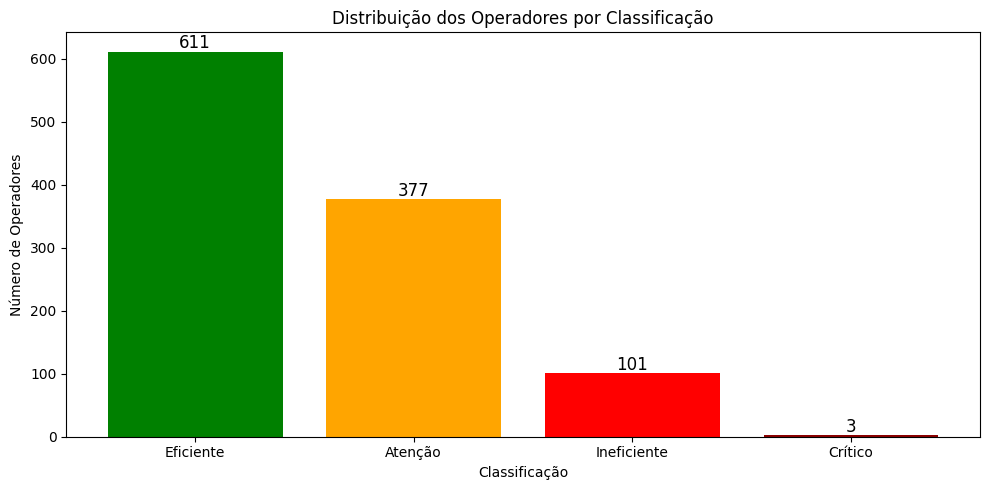

In [24]:
# Gráfico de barras mostrando quantos operadores
plt.figure(figsize=(10, 5))

# Definindo cores por classificação
cores = {
    'Eficiente': 'green',
    'Atenção': 'orange', 
    'Ineficiente': 'red',
    'Crítico': 'darkred'
}

contagem = kpis_operadores['classificacao'].value_counts()
contagem = contagem.reindex(['Eficiente', 'Atenção', 'Ineficiente', 'Crítico'])

plt.bar(
    contagem.index,
    contagem.values,
    color=[cores[c] for c in contagem.index]
)

# Adicionando valores em cima de cada barra
for i, valor in enumerate(contagem.values):
    plt.text(i, valor + 5, str(valor), ha='center', fontsize=12)

plt.title('Distribuição dos Operadores por Classificação')
plt.xlabel('Classificação')
plt.ylabel('Número de Operadores')
plt.tight_layout()
plt.savefig('distribuicao_classificacao.png', bbox_inches='tight')
plt.show()

**Distribuição das Classificações:** O gráfico mostra a distribuição dos 1.092 operadores analisados entre as quatro classificações. A maioria dos operadores (56%) é eficiente, enquanto 9.5% precisam de atenção imediata (Ineficiente ou Crítico).

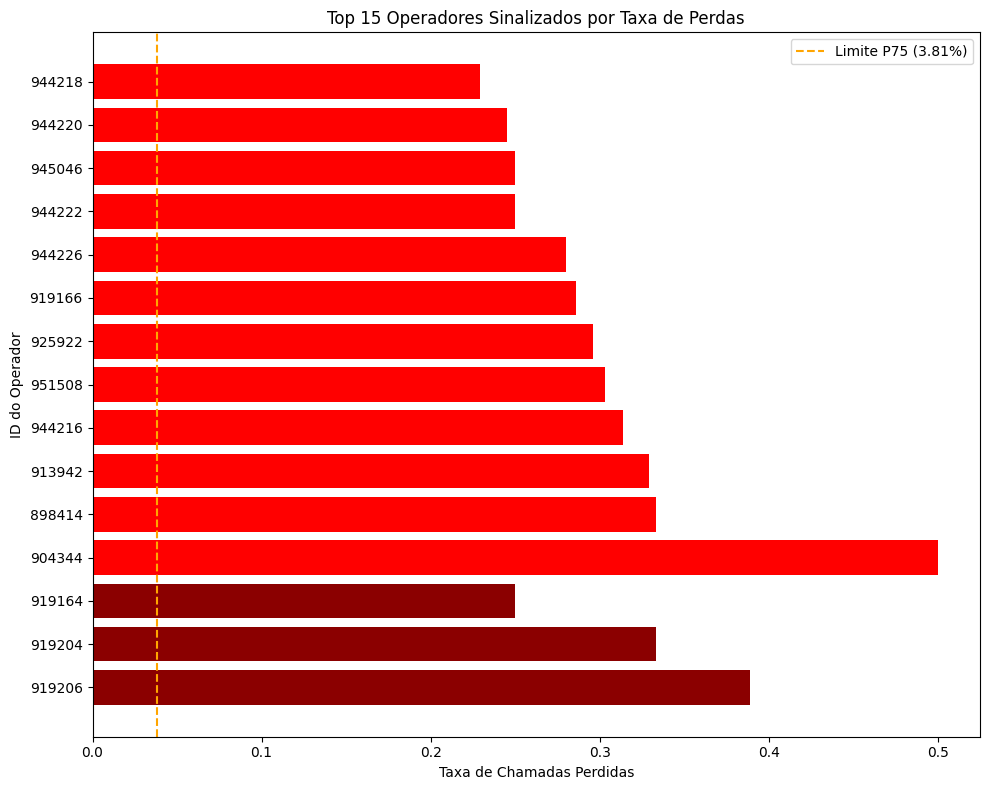

In [25]:
# Gráfico de barras horizontais mostrando a taxa de perdas dos operadores críticos e ineficientes
plt.figure(figsize=(10, 8))

# Filtrando os top 15 operadores sinalizados
top_sinalizados = sinalizados.head(15).copy()
top_sinalizados['operator_id'] = top_sinalizados['operator_id'].astype(str)

# Definindo cores por classificação
cores_ranking = top_sinalizados['classificacao'].map({
    'Crítico': 'darkred',
    'Ineficiente': 'red'
})

plt.barh(
    top_sinalizados['operator_id'],
    top_sinalizados['taxa_perdas'],
    color=cores_ranking
)

plt.title('Top 15 Operadores Sinalizados por Taxa de Perdas')
plt.xlabel('Taxa de Chamadas Perdidas')
plt.ylabel('ID do Operador')
plt.axvline(x=limite_taxa_perdas, color='orange', 
            linestyle='--', label=f'Limite P75 ({limite_taxa_perdas:.2%})')
plt.legend()
plt.tight_layout()
plt.savefig('ranking_sinalizados.png', bbox_inches='tight')
plt.show()

**Ranking dos Operadores Sinalizados:** O gráfico mostra os 15 operadores com maior taxa de chamadas perdidas entre os sinalizados. A linha laranja indica o limite do percentil 75 usado como critério de sinalização. Operadores em vermelho escuro são Críticos e em vermelho são Ineficientes.

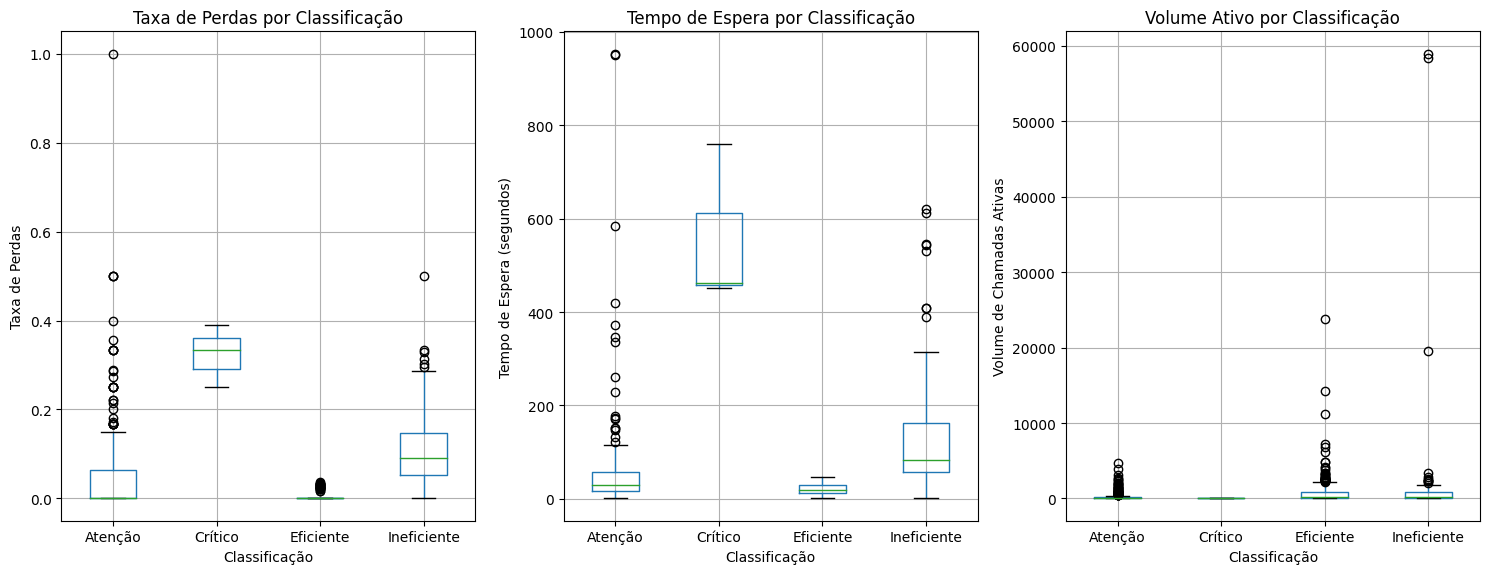

In [26]:
# Boxplots comparando a distribuição dos KPIs entre as quatro classificações de operadores
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Ordem das classificações
ordem = ['Eficiente', 'Atenção', 'Ineficiente', 'Crítico']
cores_box = ['green', 'orange', 'red', 'darkred']

# KPI 1: Taxa de perdas
kpis_operadores.boxplot(
    column='taxa_perdas',
    by='classificacao',
    ax=axes[0],
    positions=range(4)
)
axes[0].set_title('Taxa de Perdas por Classificação')
axes[0].set_xlabel('Classificação')
axes[0].set_ylabel('Taxa de Perdas')

# KPI 2: Tempo de espera
kpis_operadores.boxplot(
    column='tempo_espera',
    by='classificacao',
    ax=axes[1],
    positions=range(4)
)
axes[1].set_title('Tempo de Espera por Classificação')
axes[1].set_xlabel('Classificação')
axes[1].set_ylabel('Tempo de Espera (segundos)')

# KPI 3: Volume ativo
kpis_operadores.boxplot(
    column='volume_ativo',
    by='classificacao',
    ax=axes[2],
    positions=range(4)
)
axes[2].set_title('Volume Ativo por Classificação')
axes[2].set_xlabel('Classificação')
axes[2].set_ylabel('Volume de Chamadas Ativas')

plt.suptitle('')
plt.tight_layout()
plt.savefig('kpis_por_classificacao.png', bbox_inches='tight')
plt.show()

**Comparação dos KPIs entre Classificações:** O gráfico mostra a mediana de cada KPI por classificação, permitindo visualizar como os indicadores se diferenciam entre os grupos de operadores.

**Resumo das Visualizações Finais:** Os gráficos apresentam uma visão geral do desempenho dos operadores e ajudam a identificar os principais casos de ineficiência.

- **Distribuição das Classificações:** A maioria dos operadores, 56%, foi classificada como eficiente. Já 104 operadores (9,5%) foram sinalizados, sendo 3 críticos e 101 ineficientes.
- **KPIs por Classificação**: Os indicadores mostram diferenças claras entre os grupos. Os operadores críticos apresentam maior tempo de espera e maior taxa de chamadas perdidas, enquanto os eficientes possuem valores mais baixos nesses indicadores.

- **Ranking dos Operadores Sinalizados:** Entre os críticos, o operador 919206 apresenta taxa de perdas de 39%. Entre os ineficientes, o operador 904344 chega a 50%. Esses valores estão bem acima do limite de 3,81%, reforçando a identificação desses operadores como casos que precisam de atenção.

### 10. Conclusões e Recomendações:

**Resultados dos Testes Estatísticos:**
- **Hipótese 1:** Tempo de espera e chamadas perdidas
A hipótese foi confirmada. Existe uma relação entre o tempo de espera e as chamadas perdidas. Quanto maior o tempo de espera, maior tende a ser a quantidade de chamadas não atendidas.
- **Hipótese 2:** Chamadas internas e externas
Não foi encontrada diferença relevante entre os dois tipos de chamadas. A taxa de perdas é de 5,44% nas internas e 5,39% nas externas. Portanto, o tipo de chamada não parece afetar o desempenho dos operadores.
- **Hipótese 3:** Produtividade dos operadores de saída
Foi encontrada uma diferença significativa entre os grupos. Operadores com baixo volume realizam uma mediana de apenas 3 chamadas, enquanto os de alto volume realizam 224 chamadas.

**Perfil dos Operadores Ineficientes:**
- Foram identificados 104 operadores que precisam de atenção.
- 3 operadores foram classificados como Críticos, pois apresentam problemas nos três indicadores analisados: muitas chamadas perdidas, alto tempo de espera e baixo volume de chamadas de saída.
- Outros 101 operadores foram classificados como Ineficientes, apresentando problemas em dois dos três indicadores e, por isso, precisam de acompanhamento.

**Recomendações para os Supervisores:**
- **Operadores Críticos:** Os operadores 919206, 919204 e 919164 precisam de uma avaliação mais rápida, pois apresentam os piores resultados nos três indicadores.
- **Operadores em Atenção:** Os 377 operadores classificados como Atenção devem ser acompanhados regularmente para evitar uma piora no desempenho.
- **Operadores Ineficientes:** Os 101 operadores ineficientes podem receber treinamentos de acordo com os problemas identificados. Quem apresenta muitas chamadas perdidas pode receber treinamento de atendimento, enquanto operadores com poucas chamadas de saída podem receber acompanhamento de produtividade.

*Revisão dos limites: Os limites utilizados na análise devem ser revisados periodicamente, pois os resultados podem mudar conforme novos dados e operadores forem adicionados.*

### Tableau e Arquivo ZIP:

In [27]:
# Exportando dados para o Tableau
# Exportando o dataset completo processado
df.to_csv('telecom_processado.csv', index=False)

# Criando versão formatada do ranking para o dashboard
ranking_formatado = ranking.copy()

# Convertendo taxa de perdas para porcentagem legível
ranking_formatado['taxa_perdas_pct'] = (
    ranking_formatado['taxa_perdas'] * 100
).round(1).astype(str) + '%'

# Arredondando tempo de espera para segundos inteiros
ranking_formatado['tempo_espera_seg'] = (
    ranking_formatado['tempo_espera'].round(0).astype('Int64')
)

# Exportando o ranking formatado
ranking_formatado.to_csv('ranking_formatado.csv', index=False)

print(f"telecom_processado.csv — {df.shape[0]} linhas")
print(f"ranking_formatado.csv — {len(ranking_formatado)} linhas")
print()
print("Prévia do ranking formatado:")
print(ranking_formatado[['operator_id', 'taxa_perdas_pct',
                          'tempo_espera_seg', 'volume_ativo',
                          'classificacao']].head())

telecom_processado.csv — 41491 linhas
ranking_formatado.csv — 1092 linhas

Prévia do ranking formatado:
   operator_id taxa_perdas_pct  tempo_espera_seg  volume_ativo classificacao
0       919206           38.9%               463           1.0       Crítico
1       919204           33.3%               759           9.0       Crítico
2       919164           25.0%               450          10.0       Crítico
3       904344           50.0%                28           5.0   Ineficiente
4       898414           33.3%                76          59.0   Ineficiente
